# 20_异常值处理方法-Z-Score 标准化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节，会给大家讲解 **异常值处理方法中的 Z-Score 标准化**。这个方法常用于识别数据中的**异常值**。

### Z-Score 标准化是什么？

我们在看一组数字的时候，比如学生的考试成绩、商品的价格、气温的记录等，总会发现有些数据特别大或特别小，比如：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
考试成绩：58，60，61，62，63，98
```

其中 98 就可能是个「异常值」，因为它明显比其他值大很多。

Z-Score 标准化，就是用来判断一个数值到底「偏离」平均值多远的工具。它告诉你：

> 你这个值距离平均值有多远，是不是离群值。

### 举个例子

比如我们有这样一组体温数据（单位：℃）：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
36.5, 36.6, 36.7, 36.6, 36.8, 39.0
```

我们可以很直观地看出来，39.0℃ 比其他值高很多，可能是测错了，也可能是发烧了。

Z-Score 会告诉我们：**39.0℃ 距离整体平均值太远了，它可能是异常值。**

### Z-Score 核心点

Z-Score 的核心思想是：

> 一个数距离平均值有多远？这个距离用「标准差」来衡量。

Z-Score 公式如下：


$$
Z = \frac{x - \mu}{\sigma}
$$


- $x$：某个数据点
- $\mu$：平均值（mean）
- $\sigma$：标准差（standard deviation）
- $Z$：标准分数，Z 值

**Z 值的意思**：

- 如果 Z 值在 -2 到 2 之间，一般说明是正常的
- 如果 Z 值小于 -3，或者大于 3，通常被认为是**异常值**

### 核心逻辑

我们一步一步拆开：

**1. 平均值** $\mu$


$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$


表示这组数据的「中心位置」。

**2. 标准差** $\sigma$


$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}
$$


它衡量的是**所有数据点离平均值的远近**。标准差越大，说明数据越分散；越小说明越集中。

**3. Z 值的推导**

想法：

我们想知道一个数据点离平均值有多远，于是有了：


$$
距离 = x - \mu
$$


但这个距离有大有小，不好比较，所以我们用「标准差」来做单位：


$$
Z = \frac{x - \mu}{\sigma}
$$


也就是说，**这个数据点比平均值高了多少个“标准差”单位**。

**4. 为什么用标准差？**

用标准差来做单位的好处是：

- 把不同单位的数据变得可比（标准化）
- 任何一组数据，用了 Z 值后，都可以和别的数据比较
- 你可以很容易判断“偏离正常范围”有多远

### Z-Score 标准化判断异常值的算法流程

**步骤一：收集你的原始数据**

比如：$100, 102, 105, 103, 104, 250$

**步骤二：计算平均值（**$\mu$**）和标准差（**$\sigma$**）**

假设计算得到：

- 平均值 $\mu = 127.3$
- 标准差 $\sigma = 55.3$

**步骤三：计算每个数据的 Z 值**

对每个 $x$ 使用公式：


$$
Z = \frac{x - \mu}{\sigma}
$$


例如：

- 对于 100：


$$
Z = \frac{100 - 127.3}{55.3} \approx -0.49
$$


- 对于 250：


$$
Z = \frac{250 - 127.3}{55.3} \approx 2.22
$$


**步骤四：判断 Z 值是否超过阈值（通常是 ±3）**

如果：

- $|Z| > 3$，就是异常值
- $|Z| \leq 3$，就认为是正常值

（在实际中，有时也用 ±2.5 或 ±2 作为临界值）

### Z-Score 标准化的注意事项

- 适用于正态分布（钟形曲线）的数据
- 对于非正态分布，Z 值判断异常可能不准
- 对于大数据量，Z 值更准确；小数据量时波动较大

## 完整案例

我们选择一个**商品定价分析**的场景。当一家电商平台的数据分析师，收到一个数据集，记录了某一类产品的价格。你怀疑其中有些价格被误填（过高或过低），需要先排除这些异常值再做后续分析，比如定价策略、折扣策略等。

因此，第一步是要进行**异常值检测**，这时候我们选择使用 **Z-Score 标准化方法**。

数据集特征：

- 商品价格（单位：美元）
- 商品销量
- 类别标签（可选）

我们重点关注「价格」这一数值型变量，应用 Z-Score 对其进行标准化，识别出不合理的价格。

### 代码实现

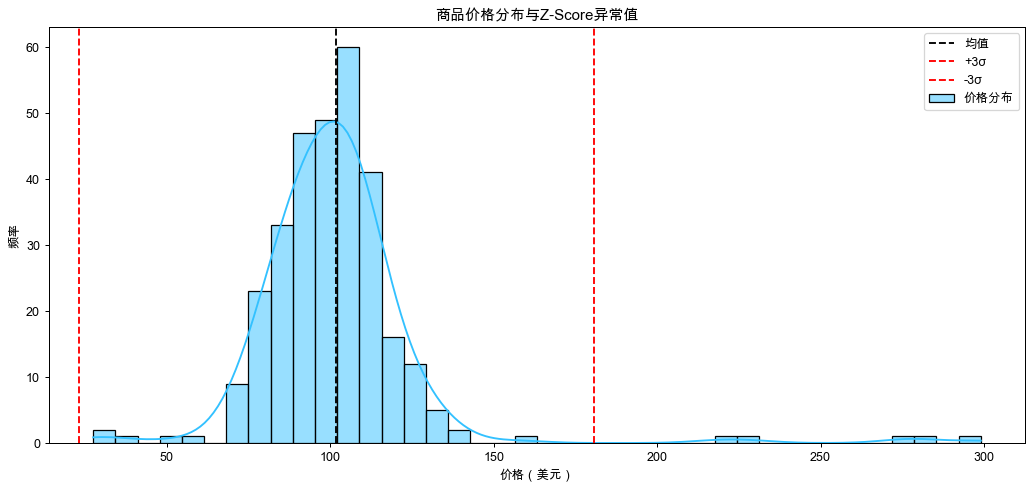

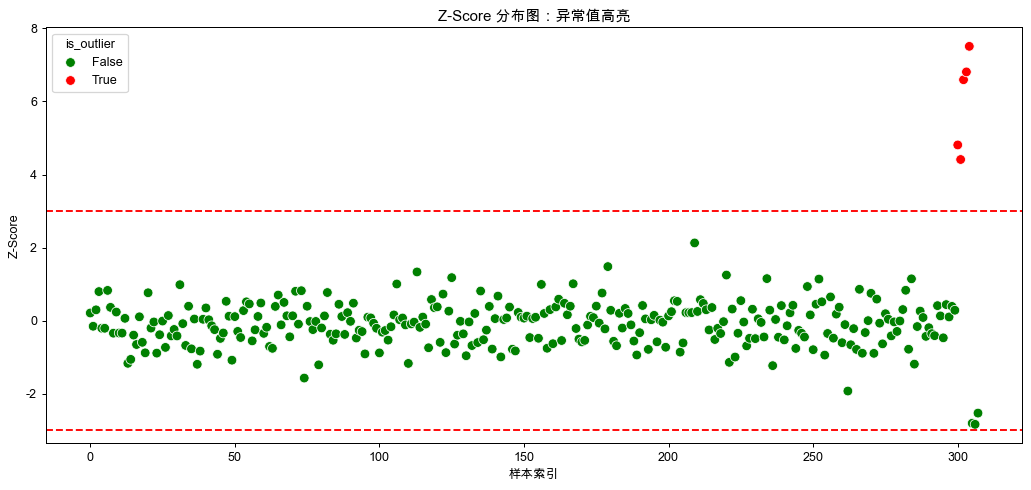


检测到的异常值如下：
          price   z_score  is_outlier
300  228.203457  4.809672        True
301  217.743954  4.411557        True
302  275.061475  6.593204        True
303  280.683474  6.807191        True
304  299.050514  7.506286        True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. 构造商品价格数据
np.random.seed(42)
normal_prices = np.random.normal(loc=100, scale=15, size=300)
outliers_high = np.random.uniform(200, 300, 5)
outliers_low = np.random.uniform(20, 40, 3)
all_prices = np.concatenate([normal_prices, outliers_high, outliers_low])

df = pd.DataFrame({'price': all_prices})

# 2. 计算 Z 值
mean_price = df['price'].mean()
std_price = df['price'].std()
df['z_score'] = (df['price'] - mean_price) / std_price

# 3. 标注异常值
df['is_outlier'] = df['z_score'].abs() > 3

# 4. 可视化：价格分布 + 异常点高亮
plt.figure(figsize=(14, 6))
sns.histplot(df['price'], bins=40, kde=True, color="#33C1FF", label="价格分布")
plt.axvline(mean_price, color='black', linestyle='--', label='均值')
plt.axvline(mean_price + 3*std_price, color='red', linestyle='--', label='+3σ')
plt.axvline(mean_price - 3*std_price, color='red', linestyle='--', label='-3σ')
plt.title("商品价格分布与Z-Score异常值")
plt.xlabel("价格（美元）")
plt.ylabel("频率")
plt.legend()
plt.show()

# 5. 可视化：Z 值分布图
plt.figure(figsize=(14, 6))
sns.scatterplot(x=range(len(df)), y=df['z_score'], hue=df['is_outlier'], palette=["green", "red"], s=60)
plt.axhline(3, color='red', linestyle='--')
plt.axhline(-3, color='red', linestyle='--')
plt.title("Z-Score 分布图：异常值高亮")
plt.xlabel("样本索引")
plt.ylabel("Z-Score")
plt.show()

# 6. 打印异常值
print("\n检测到的异常值如下：")
print(df[df['is_outlier']])

**步骤1：生成数据**

In [3]:
normal_prices = np.random.normal(loc=100, scale=15, size=300)

- 生成 300 个价格，平均值为 100，标准差为 15，模拟「正常价格分布」
- `loc` 是均值，`scale` 是标准差

In [4]:
outliers_high = np.random.uniform(200, 300, 5)
outliers_low = np.random.uniform(20, 40, 3)

- 人工添加 8 个明显偏离的数据（高得离谱，低得不正常）

In [5]:
all_prices = np.concatenate([normal_prices, outliers_high, outliers_low])

- 将正常值和异常值合并，构成我们要分析的价格数据

**步骤2：Z-Score 标准化**

In [6]:
mean_price = df['price'].mean()
std_price = df['price'].std()
df['z_score'] = (df['price'] - mean_price) / std_price

这是核心步骤，计算每个价格的 Z 值。Z 值大于 3 或小于 -3 被视为异常值。

**步骤3：判断异常值**

In [7]:
df['is_outlier'] = df['z_score'].abs() > 3

用绝对值判断，Z 值大于 3 的视为「异常点」，用布尔变量记录。

**步骤4：价格分布可视化**

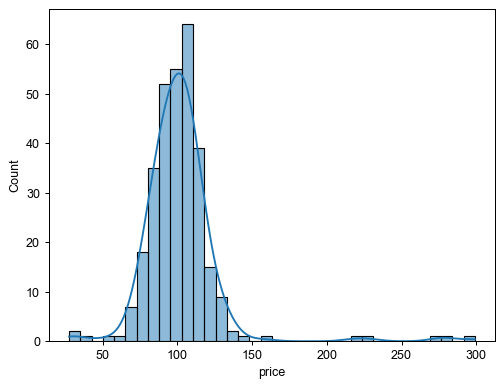

In [8]:
sns.histplot(df['price'], kde=True)
plt.show()

- 绘制直方图 + 核密度曲线，显示整体分布形态
- 用红色虚线标出 ±3σ 区间外，即 Z 值超过 3 的界限

![原文参考图，当前结果见代码输出](attachments/img_021.png)

**步骤5：Z 值分布图**

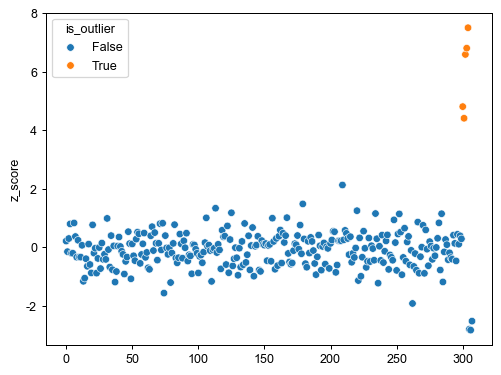

In [9]:
sns.scatterplot(x=np.arange(len(df)), y=df['z_score'], hue=df['is_outlier'])
plt.show()

- 横坐标是索引（为了展示点的位置），纵坐标是 Z 值
- 使用红/绿两色区分异常点与正常点，一目了然

![原文参考图，当前结果见代码输出](attachments/img_022.png)

**步骤6：输出异常值**

In [10]:
print(df[df['is_outlier']])

          price   z_score  is_outlier
300  228.203457  4.809672        True
301  217.743954  4.411557        True
302  275.061475  6.593204        True
303  280.683474  6.807191        True
304  299.050514  7.506286        True


展示被标记为异常的记录，可以进一步删除、修正或标注。

### 分析与解释：哪些是异常值、为什么？

在我们的案例中：

- 正常价格大多集中在 85\~115 之间
- 添加的异常值如 250、275、30、35 等，Z 值明显超过 ±3
- 这些值不是因为市场规律而产生的，而是：

  - 人为误输
  - 爬虫错误
  - 数据单位错写

这些都属于应清洗的数据。

图像直观地显示了哪些点离群，红色的点在 Z 值图中高高在上或远低于下界。

### Z-Score 标准化的优点与缺点

**优点**：

1. **简洁直观**：只需知道平均值和标准差，就能判断一个点是否异常。
2. **标准化能力强**：不同数据集之间可以通用比较，因为都是以「标准差单位」度量。
3. **可扩展性好**：可以快速应用到多维度上，比如多变量联合判断。
4. **与正态分布模型契合度高**：如果数据服从正态分布，Z-Score 判断异常是非常准确的。

**缺点**：

1. **对分布形状敏感**：如果数据不是正态分布，Z 值的判断可能不准（比如偏态分布会误判正常值为异常）。
2. **受极端值影响大**：极端值本身会影响均值和标准差，使得标准化的效果变差，甚至掩盖其他异常值。
3. **不适用于分类变量或离散变量**：只能用于连续型数值数据。
4. **静态阈值限制**：阈值 ±3 只是经验值，某些业务场景可能需更灵活判断。

### Z-Score 方法的适用场景与限制

**适合的情况**：

- 数据服从或近似服从**正态分布**
- 对数值型数据，尤其是单一维度的分析
- 数据量足够大时，统计特性较稳定
- 异常值显著偏离均值，不是渐变异常（而是跳变）

**不适合的情况**：

- 数据为**严重偏态分布**（如收入分布、销售分布）
- 有很多重复值或离散型数据（如1、2、3评分）
- 异常值不明显或逐渐变化（如行为欺诈、渐进攻击）
- 数据中本身含噪或有明显季节性

## 总结

Z-Score 方法的**最大优势在于其直观性和简单性**，可以快速对数据做初步清洗，适合做前期的数据探索（EDA）或异常值识别任务。尤其在电商、金融、传感器信号处理、工业质量控制等领域，都是极常用的工具。

但需要注意的是，Z-Score 方法的适用前提是**数据的标准差和均值能够客观反映中心趋势和离散程度**。在严重偏态或异常点占比很高的情况下，Z 值容易失真。

因此，在实际使用中，我们往往会：

- 先用可视化判断数据分布形态
- 结合业务知识设定合理的 Z 值阈值（如 ±2.5）
- 与其他方法（如 IQR、MAD）联合使用，提高鲁棒性

例如：**IQR方法（四分位数）** 或 **Isolation Forest**。